In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import TSNE

# =========================================================
# STEP 1: Load MNIST from IDX files (your current structure)
# =========================================================
BASE = "archive" 
TRAIN_IMG = f"{BASE}/train-images.idx3-ubyte"
TRAIN_LBL = f"{BASE}/train-labels.idx1-ubyte"
TEST_IMG  = f"{BASE}/t10k-images.idx3-ubyte"
TEST_LBL  = f"{BASE}/t10k-labels.idx1-ubyte"

def load_images_idx(filename):
    with open(filename, "rb") as f:
        _magic = int.from_bytes(f.read(4), "big")
        n = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_labels_idx(filename):
    with open(filename, "rb") as f:
        _magic = int.from_bytes(f.read(4), "big")
        n = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n,)

x_train_full = load_images_idx(TRAIN_IMG)
y_train_full = load_labels_idx(TRAIN_LBL)
x_test_full  = load_images_idx(TEST_IMG)
y_test_full  = load_labels_idx(TEST_LBL)

print("Loaded:")
print("Train:", x_train_full.shape, y_train_full.shape)
print("Test :", x_test_full.shape, y_test_full.shape)

Loaded:
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


In [ ]:
# =========================================================
# STEP 2: Sample digits {0,1,2} (100 each) for Train & Test
# =========================================================
np.random.seed(42)
classes = [0, 1, 2]
n_samples = 100

def sample_n_per_class(x, y, classes, n):
    xs, ys = [], []
    for c in classes:
        idx = np.where(y == c)[0]
        picked = np.random.choice(idx, n, replace=False)
        xs.append(x[picked])
        ys.append(y[picked])
    xs = np.concatenate(xs, axis=0)
    ys = np.concatenate(ys, axis=0)
    perm = np.random.permutation(len(ys))
    return xs[perm], ys[perm]

x_train, y_train = sample_n_per_class(x_train_full, y_train_full, classes, n_samples)
x_test,  y_test  = sample_n_per_class(x_test_full,  y_test_full,  classes, n_samples)

print("\nSampled:")
print("Train:", x_train.shape, y_train.shape, "classes:", {c: int(np.sum(y_train==c)) for c in classes})
print("Test :", x_test.shape,  y_test.shape,  "classes:", {c: int(np.sum(y_test==c)) for c in classes})


Sampled:
Train: (300, 28, 28) (300,) classes: {0: 100, 1: 100, 2: 100}
Test : (300, 28, 28) (300,) classes: {0: 100, 1: 100, 2: 100}


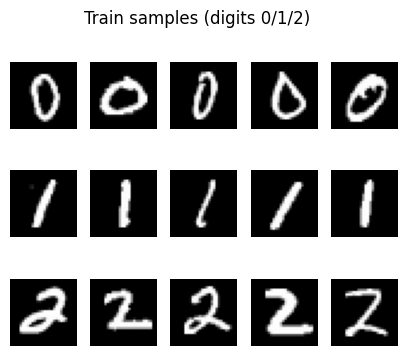

In [ ]:
# =========================================================
#  Show 5 sample images per class (0/1/2)
# =========================================================
samples = {c: [] for c in classes}
for i in range(len(y_train)):
    c = int(y_train[i])
    if len(samples[c]) < 5:
        samples[c].append(x_train[i])

plt.figure(figsize=(5, 4))
for i, c in enumerate(classes):
    for j in range(5):
        plt.subplot(len(classes), 5, i * 5 + j + 1)
        plt.imshow(samples[c][j], cmap="gray")
        plt.axis("off")
plt.suptitle("Train samples (digits 0/1/2)")
plt.show()


In [ ]:
# =========================================================
# STEP 3: Vectorize + Normalize
# =========================================================
x_train_vec = x_train.reshape(x_train.shape[0], -1).astype(np.float64) / 255.0
x_test_vec  = x_test.reshape(x_test.shape[0], -1).astype(np.float64) / 255.0
d = x_train_vec.shape[1]

In [ ]:
# =========================================================
# STEP 4: MLE estimates for mean and covariance
# =========================================================
eps = 1e-3  
mean_of_classes = {}
cov_of_classes = {}
prior = {}
for c in classes:
    Xc = x_train_vec[y_train == c] 
    Nc = Xc.shape[0]
    prior[c] = Nc / x_train_vec.shape[0]
    mu = (1.0 / Nc) * np.sum(Xc, axis=0) 
    Xm = Xc - mu
    Sigma = (1.0 / Nc) * (Xm.T @ Xm)       
    Sigma = Sigma + eps * np.eye(d)
    mean_of_classes[c] = mu
    cov_of_classes[c] = Sigma
inv_cov = {}
logdet_cov = {}
for c in classes:
    inv_cov[c] = np.linalg.inv(cov_of_classes[c])
    sign, ld = np.linalg.slogdet(cov_of_classes[c])
    logdet_cov[c] = ld

In [ ]:
# =========================================================
# STEP 5: Implement QDA discriminant + Predict + Accuracy
# =========================================================
def qda_discriminant(x, c):
    mu = mean_of_classes[c]
    diff = x - mu
    return (-0.5 * logdet_cov[c]
            -0.5 * (diff.T @ inv_cov[c] @ diff)
            + np.log(prior[c]))

def predict(X, disc_fn):
    preds = np.empty(X.shape[0], dtype=int)
    for i in range(X.shape[0]):
        scores = [disc_fn(X[i], c) for c in classes]
        preds[i] = classes[int(np.argmax(scores))]
    return preds

y_pred_qda = predict(x_test_vec, qda_discriminant)
acc_qda = np.mean(y_pred_qda == y_test) * 100
print("\nQDA Accuracy (%):", acc_qda)

for c in classes:
    mask = (y_test == c)
    print(f"QDA accuracy for class {c} (%):", np.mean(y_pred_qda[mask] == y_test[mask]) * 100)



QDA Accuracy (%): 99.33333333333333
QDA accuracy for class 0 (%): 100.0
QDA accuracy for class 1 (%): 99.0
QDA accuracy for class 2 (%): 99.0


In [ ]:
# =========================================================
# STEP 6: Implement LDA discriminant + Predict + Accuracy
# =========================================================
Sigma_shared = np.zeros((d, d), dtype=np.float64)
N_total = x_train_vec.shape[0]

for c in classes:
    Xc = x_train_vec[y_train == c]
    Xm = Xc - mean_of_classes[c]
    Sigma_shared += (Xm.T @ Xm)

Sigma_shared = (1.0 / N_total) * Sigma_shared + eps * np.eye(d)
inv_S_shared = np.linalg.inv(Sigma_shared)
sign, ld_shared = np.linalg.slogdet(Sigma_shared)

def lda_discriminant(x, c):
    mu = mean_of_classes[c]
    diff = x - mu
    return (-0.5 * ld_shared
            -0.5 * (diff.T @ inv_S_shared @ diff)
            + np.log(prior[c]))

y_pred_lda = predict(x_test_vec, lda_discriminant)
acc_lda = np.mean(y_pred_lda == y_test) * 100
print("\nLDA Accuracy (%):", acc_lda)



LDA Accuracy (%): 91.66666666666666


In [ ]:
# =========================================================
# STEP 7: Discriminant values of ONE sample test point
# =========================================================
sample_idx = 0
x0 = x_test_vec[sample_idx]
true_y0 = int(y_test[sample_idx])

qda_vals = {c: qda_discriminant(x0, c) for c in classes}
lda_vals = {c: lda_discriminant(x0, c) for c in classes}

print("\nSample test point:", sample_idx, "True label:", true_y0)
print("QDA discriminants:", qda_vals)
print("LDA discriminants:", lda_vals)


Sample test point: 0 True label: 0
QDA discriminants: {0: np.float64(-557.0315301839598), 1: np.float64(-34201.41489419173), 2: np.float64(-10321.90143197601)}
LDA discriminants: {0: np.float64(1184.3628643125771), 1: np.float64(781.3821116676875), 2: np.float64(930.0837115333202)}


C:\Users\ADITRI JAIN\AppData\Local\Temp\ipykernel_37472\3156313270.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


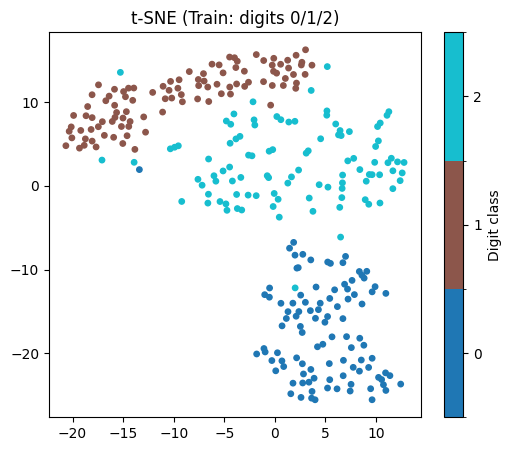

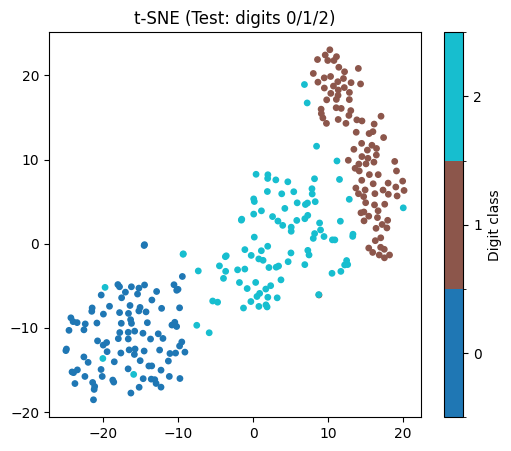


Color mapping (matplotlib 'tab10'):
Digit 0 -> tab10[0]
Digit 1 -> tab10[1]
Digit 2 -> tab10[2]


In [10]:
# =========================================================
# STEP 8: t-SNE plots for Train & Test + explicit color mapping
# =========================================================
cmap = plt.cm.get_cmap("tab10", 3) 
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
train_2d = tsne.fit_transform(x_train_vec)
plt.figure(figsize=(6, 5))
sc = plt.scatter(train_2d[:, 0], train_2d[:, 1], c=y_train, s=15, cmap=cmap, norm=norm)
cb = plt.colorbar(sc, ticks=[0, 1, 2])
cb.set_label("Digit class")
plt.title("t-SNE (Train: digits 0/1/2)")
plt.show()
test_2d = tsne.fit_transform(x_test_vec)
plt.figure(figsize=(6, 5))
sc = plt.scatter(test_2d[:, 0], test_2d[:, 1], c=y_test, s=15, cmap=cmap, norm=norm)
cb = plt.colorbar(sc, ticks=[0, 1, 2])
cb.set_label("Digit class")
plt.title("t-SNE (Test: digits 0/1/2)")
plt.show()
print("\nColor mapping (matplotlib 'tab10'):")
print("Digit 0 -> tab10[0]")
print("Digit 1 -> tab10[1]")
print("Digit 2 -> tab10[2]")